In [2]:
"""
EV Forecast Model Training Notebook
Trains a Linear Regression model to predict EV adoption trends
"""

import os
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from datetime import datetime
import json


In [3]:
# -----------------------------
# 1. Project Paths
# -----------------------------
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_PATH = os.path.join(BASE_DIR, "data", "final_master_report.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "ev_forecast_model.pkl")
METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")

print("=" * 70)
print("🚗 EV FORECAST MODEL TRAINING")
print("=" * 70)
print(f"📂 Data path: {DATA_PATH}")
print(f"💾 Model path: {MODEL_PATH}")
print(f"📊 Metrics path: {METRICS_PATH}")


🚗 EV FORECAST MODEL TRAINING
📂 Data path: E:\JupyterProject\EV-Infrastructure-Intelligence\data\final_master_report.csv
💾 Model path: E:\JupyterProject\EV-Infrastructure-Intelligence\models\ev_forecast_model.pkl
📊 Metrics path: E:\JupyterProject\EV-Infrastructure-Intelligence\models\model_metrics.json


In [4]:
# -----------------------------
# 2. Load Dataset
# -----------------------------
try:
    df = pd.read_csv(DATA_PATH)
    print("✅ Dataset loaded successfully")
    print(f"📊 Shape: {df.shape}")
    print(f"📋 Columns: {list(df.columns)[:5]}...")
    print(f"🏢 RTOs: {df['RTO Office'].nunique()}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"❌ Data file not found at {DATA_PATH}. "
        "Ensure 'final_master_report.csv' exists in data/"
    )

df.head()


✅ Dataset loaded successfully
📊 Shape: (970, 6)
📋 Columns: ['Fuel', '2025', '2024', '2023', '2022']...
🏢 RTOs: 62


,Fuel,2025,2024,2023,2022,RTO Office
0,CNG ONLY,266,220,74,24,AKLUJ-MH45
1,DIESEL,8973,6295,5602,6221,AKLUJ-MH45
2,DIESEL/HYBRID,1,0,0,1,AKLUJ-MH45
3,ELECTRIC(BOV),207,1264,1029,545,AKLUJ-MH45
4,ETHANOL,1,0,0,0,AKLUJ-MH45


In [5]:
# -----------------------------
# 3. Identify Year Columns
# -----------------------------
year_cols = sorted([col for col in df.columns if col.isdigit()], key=int)

print(f"📅 Year columns detected: {year_cols}")
print(f"📅 Date range: {year_cols[0]} → {year_cols[-1]}")


📅 Year columns detected: ['2022', '2023', '2024', '2025']
📅 Date range: 2022 → 2025


In [6]:
# -----------------------------
# 4. Enhanced Fuel Categorization
# -----------------------------
def categorize_fuel(fuel):
    fuel = str(fuel).upper()
    if any(k in fuel for k in ["EV", "ELECTRIC", "BEV", "E-VEHICLE"]):
        return "EV"
    if any(k in fuel for k in ["HYBRID", "PHEV", "HEV"]):
        return "HYBRID"
    if "CNG" in fuel:
        return "CNG"
    if any(k in fuel for k in ["PETROL", "GASOLINE"]):
        return "PETROL"
    if "DIESEL" in fuel:
        return "DIESEL"
    if "LPG" in fuel:
        return "LPG"
    return "OTHER"

df["Category"] = df["Fuel"].apply(categorize_fuel)

df["Category"].value_counts()


Category
HYBRID    199
EV        197
CNG       187
PETROL    172
OTHER     110
DIESEL     63
LPG        42
Name: count, dtype: int64

In [7]:
# -----------------------------
# 5. Filter & Aggregate EV Data
# -----------------------------
ev_df = df[df["Category"] == "EV"]

print(f"🚗 EV records: {ev_df.shape[0]:,}")
print(f"🏢 RTOs with EV data: {ev_df['RTO Office'].nunique()}")

X = np.array([int(y) for y in year_cols]).reshape(-1, 1)
y = ev_df[year_cols].sum().values

print("\n📈 Aggregated EV Registrations")
print(f"{'Year':<10}{'EVs':>15}")
print("-" * 25)
for yr, cnt in zip(X.flatten(), y):
    print(f"{yr:<10}{int(cnt):>15,}")


🚗 EV records: 197
🏢 RTOs with EV data: 62

📈 Aggregated EV Registrations
Year                  EVs
-------------------------
2022              159,291
2023              224,549
2024              284,521
2025              320,581


In [8]:
# -----------------------------
# 6. Train Linear Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print("📊 Model Performance")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Slope    : {model.coef_[0]:,.2f} EVs/year")
print(f"Intercept: {model.intercept_:,.2f}")


📊 Model Performance
R² Score : 0.9847
MAE      : 7,299.50
RMSE     : 7,590.74
MAPE     : 3.03%
Slope    : 54,384.20 EVs/year
Intercept: -109,799,193.20


In [9]:
# -----------------------------
# 7. Save Model with Metadata
# -----------------------------
os.makedirs(MODEL_DIR, exist_ok=True)

model_data = {
    "model": model,
    "year_cols": year_cols,
    "r2_score": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "slope": model.coef_[0],
    "intercept": model.intercept_,
    "trained_on": datetime.now().isoformat(),
    "training_years": X.flatten().tolist(),
    "training_values": y.tolist(),
    "predicted_values": y_pred.tolist()
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_data, f)

metrics_data = {
    "r2_score": r2,
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
    "trained_on": datetime.now().isoformat(),
    "year_range": f"{year_cols[0]}-{year_cols[-1]}"
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics_data, f, indent=4)

print("💾 Model and metrics saved successfully")


💾 Model and metrics saved successfully


In [10]:
# -----------------------------
# 8. Generate Predictions
# -----------------------------
forecast_years = 5
last_year = int(year_cols[-1])
test_years = np.array([[last_year + i] for i in range(1, forecast_years + 1)])
predictions = model.predict(test_years)

print(f"{'Year':<10}{'Predicted EVs':>20}{'Growth %':>15}")
print("-" * 45)

prev = y[-1]
for yr, pred in zip(test_years.flatten(), predictions):
    growth = ((pred - prev) / prev) * 100
    print(f"{yr:<10}{int(pred):>20,}{growth:>14.1f}%")
    prev = pred

cagr = (predictions[-1] / y[-1]) ** (1 / forecast_years) - 1
print(f"\n📈 Projected CAGR: {cagr * 100:.2f}%")


Year             Predicted EVs       Growth %
---------------------------------------------
2026                   383,196          19.5%
2027                   437,580          14.2%
2028                   491,964          12.4%
2029                   546,348          11.1%
2030                   600,732          10.0%

📈 Projected CAGR: 13.38%


In [11]:
# -----------------------------
# 9. Validation & Testing
# -----------------------------
with open(MODEL_PATH, "rb") as f:
    loaded = pickle.load(f)

loaded_model = loaded["model"]
test_pred = loaded_model.predict(test_years)

print("✅ Model reload successful")
print("✅ Prediction consistency:",
      "PASSED" if np.allclose(predictions, test_pred) else "FAILED")


✅ Model reload successful
✅ Prediction consistency: PASSED


**GRAPHS**

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.arima.model import ARIMA

sns.set(style="whitegrid")

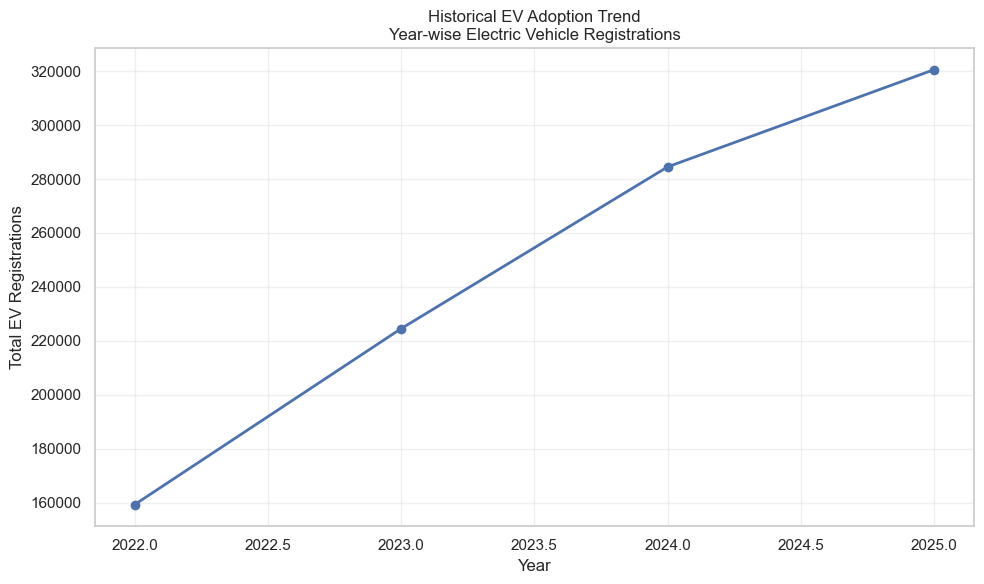

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(X.flatten(), y, marker='o', linewidth=2)

plt.title(
    "Historical EV Adoption Trend\n"
    "Year-wise Electric Vehicle Registrations"
)
plt.xlabel("Year")
plt.ylabel("Total EV Registrations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

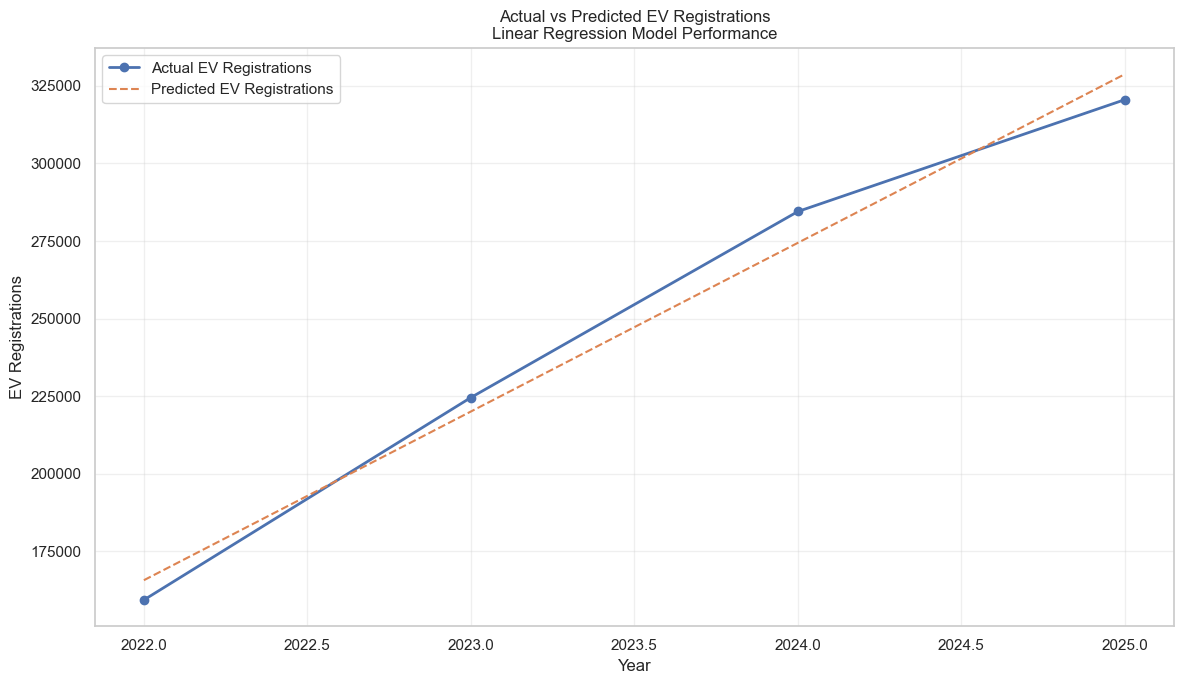

In [30]:
plt.figure(figsize=(12, 7))

plt.plot(X.flatten(), y, marker='o', linewidth=2, label="Actual EV Registrations")
plt.plot(X.flatten(), y_pred, linestyle='--', label="Predicted EV Registrations")

plt.title(
    "Actual vs Predicted EV Registrations\n"
    "Linear Regression Model Performance"
)
plt.xlabel("Year")
plt.ylabel("EV Registrations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

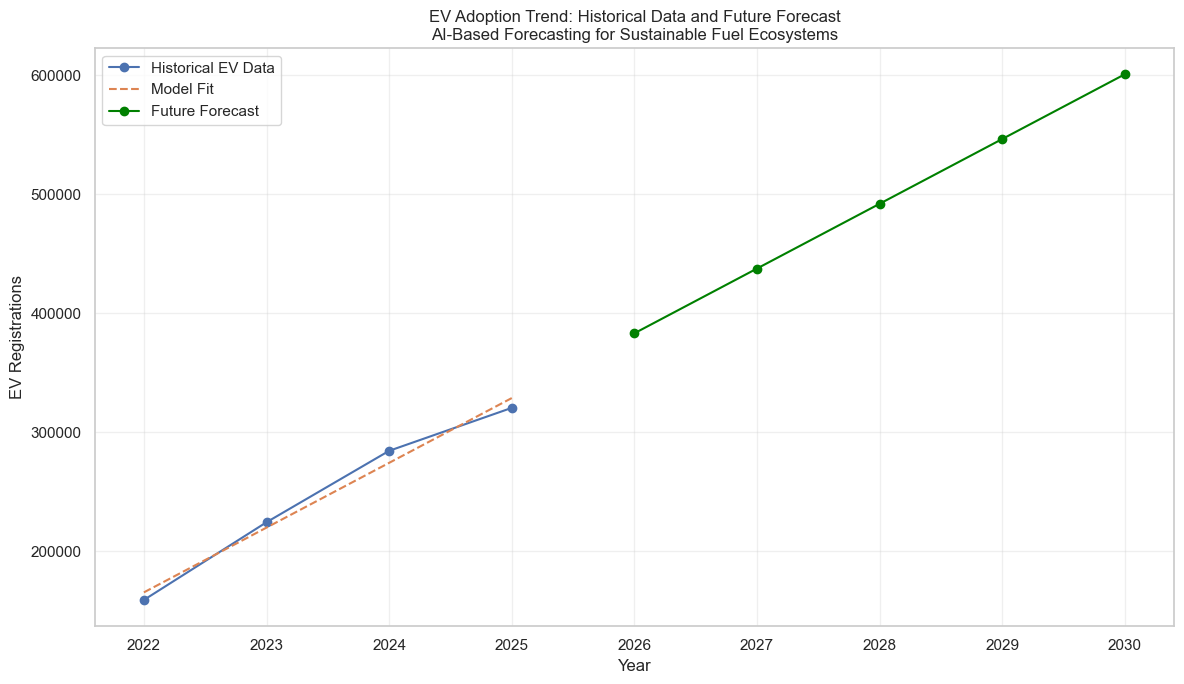

In [31]:
plt.figure(figsize=(12, 7))

plt.plot(X.flatten(), y, marker='o', label="Historical EV Data")
plt.plot(X.flatten(), y_pred, linestyle='--', label="Model Fit")
plt.plot(test_years.flatten(), predictions, marker='o', color='green', label="Future Forecast")

plt.title(
    "EV Adoption Trend: Historical Data and Future Forecast\n"
    "AI-Based Forecasting for Sustainable Fuel Ecosystems"
)
plt.xlabel("Year")
plt.ylabel("EV Registrations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Polynomial Regression Model**

In [32]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)

poly_r2 = r2_score(y, y_pred_poly)
poly_mae = mean_absolute_error(y, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y, y_pred_poly))

print("Polynomial Regression Metrics")
print(f"R²   : {poly_r2:.4f}")
print(f"MAE  : {poly_mae:,.2f}")
print(f"RMSE : {poly_rmse:,.2f}")

Polynomial Regression Metrics
R²   : 0.9988
MAE  : 1,862.60
RMSE : 2,082.45


**ARIMA Model (SAFE for Small Dataset)**

In [34]:
arima_model = ARIMA(y, order=(1, 1, 1))
arima_result = arima_model.fit()

y_pred_arima = arima_result.predict(start=1, end=len(y)-1)
y_actual_arima = y[1:]

min_len = min(len(y_actual_arima), len(y_pred_arima))
y_actual_arima = y_actual_arima[:min_len]
y_pred_arima = y_pred_arima[:min_len]

arima_r2 = r2_score(y_actual_arima, y_pred_arima)
arima_mae = mean_absolute_error(y_actual_arima, y_pred_arima)
arima_rmse = np.sqrt(mean_squared_error(y_actual_arima, y_pred_arima))

print("ARIMA Metrics (Experimental)")
print(f"R²   : {arima_r2:.4f}")
print(f"MAE  : {arima_mae:,.2f}")
print(f"RMSE : {arima_rmse:,.2f}")

ARIMA Metrics (Experimental)
R²   : 0.9743
MAE  : 5,740.84
RMSE : 6,349.14


E:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
